In [1]:
# 1. Setup Environment
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.3 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [2]:
!pip install roboflow
import os
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import display, Image
from roboflow import Roboflow
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# 2. LOAD DATASET
# ------------------------------
print("\n📦 Loading dataset from Roboflow...")
rf = Roboflow(api_key="KFR7Hm4hRwUMZVQOAXc3")
project = rf.workspace("accident-detection-model").project("accident-detection-model")
dataset = project.version(2).download("yolov8")


# Verify dataset
print("\n🔍 Dataset verification:")
print(f"Location: {dataset.location}")
print("\nSample training images:")
!ls {dataset.location}/train/images | head -3


📦 Loading dataset from Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Accident-detection-model-2 in yolov8:: 100%|██████████| 6512/6512 [00:00<00:00, 8743.16it/s] 



🔍 Dataset verification:
Location: /kaggle/working/Accident-detection-model-2

Sample training images:
5_10_jpg.rf.5639f7a69885c595fc4b54e55dbf5148.jpg
5_11_jpg.rf.99ee6f27d5d5f353e00506003993302a.jpg
5_12_jpg.rf.f46713998d4579eabe3baf01d0bc605c.jpg
ls: write error: Broken pipe


In [4]:
# 3. MODEL TRAINING WITH IMPROVEMENTS
# ------------------------------
print("\n⚙️ Configuring model training...")
model = YOLO("yolov8m.pt")


⚙️ Configuring model training...


In [6]:
# Training configuration
import torch

device = 0 if torch.cuda.is_available() else "cpu"

results = model.train(
    data=f"{dataset.location}/data.yaml",

    # Training
    epochs=100,
    patience=25,

    # Image & batch (A100 power 💪)
    imgsz=640,
    batch=32,                 # A100 can handle this
    device=device,

    # Augmentations (balanced)
    augment=True,
    fliplr=0.5,
    degrees=5.0,
    scale=0.5,
    translate=0.1,

    # mAP optimization
    mixup=0.1,
    copy_paste=0.1,
    close_mosaic=10,

    # Monitoring
    name="accident_yolov8m_a100",
    save=True,
    save_period=10,
    plots=True
)

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Accident-detection-model-2/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=accident_yolov8m_a100, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto


📊 Evaluating model performance...
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1236.1±251.3 MB/s, size: 58.4 KB)
val: Scanning /kaggle/working/Accident-detection-model-2/test/labels... 362 images, 186 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362 1.8Kit/s 0.2s<0.0s
val: New cache created: /kaggle/working/Accident-detection-model-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 4.2it/s 5.4s0.2s
                   all        362        204      0.826      0.862      0.843      0.441
Speed: 1.4ms preprocess, 10.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

🚗 MODEL PERFORMANCE REPORT 🚗
📍 Precision: 0.826 (Correct predictions)
📍 Recall: 0.862 (Accidents detected)
📍 mA

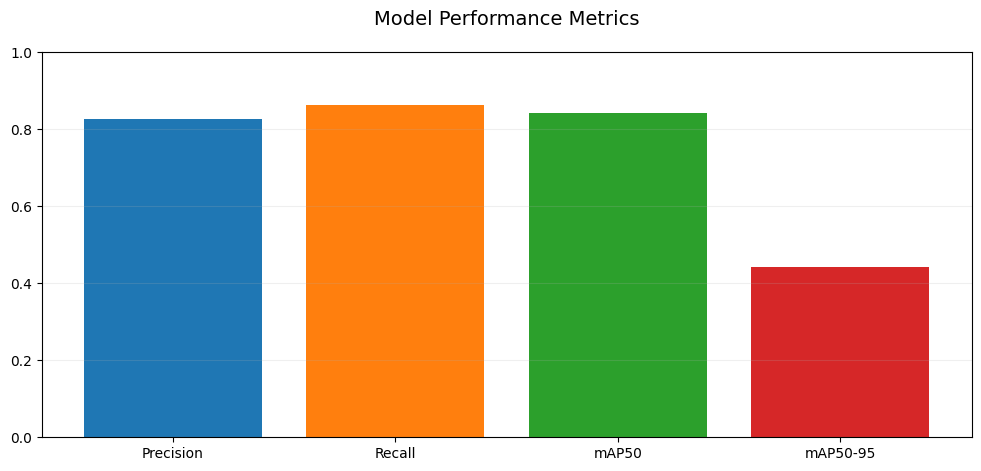

In [7]:
import numpy as np
# 4. VALIDATION & METRICS
# ------------------------------
print("\n📊 Evaluating model performance...")
metrics = model.val(
    data=f'{dataset.location}/data.yaml',
    split='test',
    conf=0.25,
    iou=0.50,
    plots=True
)

# Process metrics
def safe_metric(metric):
    return float(metric[0]) if isinstance(metric, np.ndarray) else metric

metrics_dict = {
    'Precision': safe_metric(metrics.box.p),
    'Recall': safe_metric(metrics.box.r),
    'mAP50': safe_metric(metrics.box.map50),
    'mAP50-95': safe_metric(metrics.box.map)
}

# Display metrics
print("\n🚗 MODEL PERFORMANCE REPORT 🚗")
print(f"📍 Precision: {metrics_dict['Precision']:.3f} (Correct predictions)")
print(f"📍 Recall: {metrics_dict['Recall']:.3f} (Accidents detected)")
print(f"📍 mAP50: {metrics_dict['mAP50']:.3f} (Detection quality)")
print(f"📍 mAP50-95: {metrics_dict['mAP50-95']:.3f} (Localization)")

# Visualization
plt.figure(figsize=(12, 5))
plt.bar(metrics_dict.keys(), metrics_dict.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Model Performance Metrics', pad=20, fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.2)
plt.show()


In [8]:
!zip -r kaggle_working_full.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/Accident-detection-model-2/ (stored 0%)
  adding: kaggle/working/Accident-detection-model-2/README.roboflow.txt (deflated 45%)
  adding: kaggle/working/Accident-detection-model-2/data.yaml (deflated 47%)
  adding: kaggle/working/Accident-detection-model-2/README.dataset.txt (deflated 27%)
  adding: kaggle/working/Accident-detection-model-2/test/ (stored 0%)
  adding: kaggle/working/Accident-detection-model-2/test/labels/ (stored 0%)
  adding: kaggle/working/Accident-detection-model-2/test/labels/Accidents-online-video-cutter_com-_mp4-1263_jpg.rf.03a5fe633835b48fff863d5dd2478745.txt (deflated 37%)
  adding: kaggle/working/Accident-detection-model-2/test/labels/ezgif-frame-125_jpg.rf.081d0164d700469c4e2d6ae37c11a1f1.txt (deflated 12%)
  adding: kaggle/working/Accident-detection-model-2/test/labels/OIF-5-_jpeg.rf.a288810984db73c67e61966bca0ef4ce.txt (deflated 19%)
  adding: kaggle/working/Accident-detection-model-2/test/labels